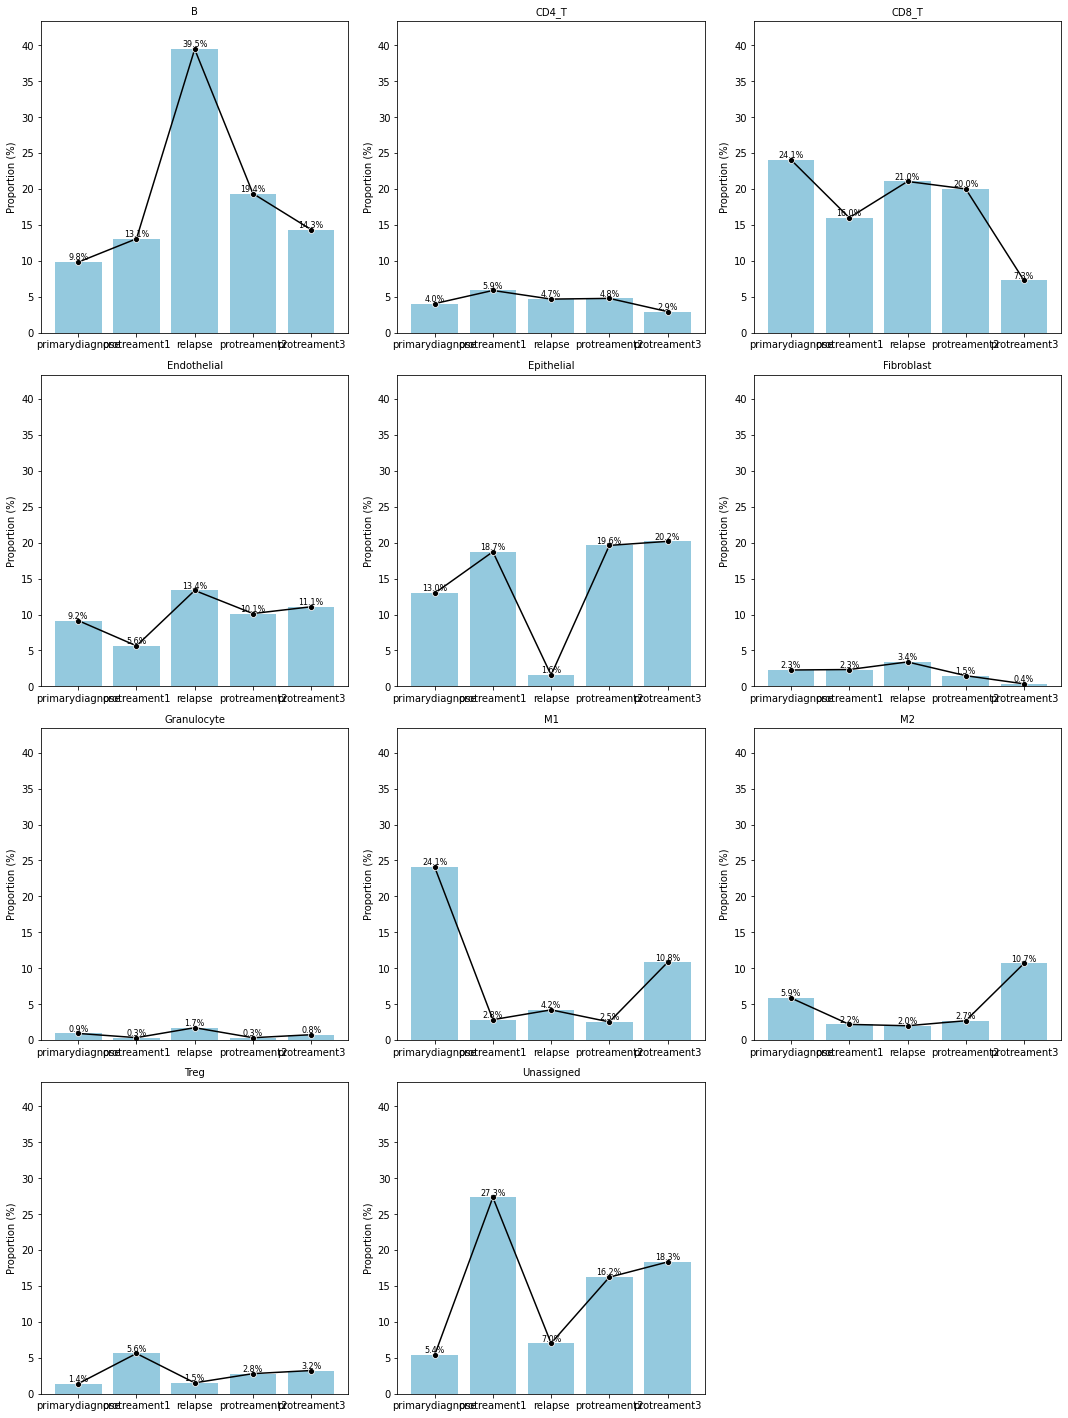

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ 读取数据
df = pd.read_csv(r"C:\Users\Li Chujia\Desktop\cell_annotationV2\annotated_cells_mixed.csv", encoding='gbk')

# 2️⃣ 映射疾病时期
stage_map = {
    "T005": "primarydiagnose",
    "T006": "protreament1",
    "T001": "relapse",
    "T002": "protreament2",
    "T004": "protreament3"
}
df["Stage"] = df["标签"].map(stage_map)

# 3️⃣ 仅保留 T004 的 ROI007–ROI010，其余时期保留全部
mask = (df["标签"] != "T004") | (df["子标签"].isin(["ROI008", "ROI009", "ROI010"]))
df_filtered = df[mask].copy()

# 4️⃣ 统计每个阶段、每种细胞类型的数量与占比
count_df = df_filtered.groupby(["Stage", "cell_type"]).size().reset_index(name="count")
total_per_stage = count_df.groupby("Stage")["count"].transform("sum")
count_df["percent"] = count_df["count"] / total_per_stage * 100

# 5️⃣ 按指定顺序排列阶段
stage_order = ["primarydiagnose", "protreament1", "relapse", "protreament2", "protreament3"]
count_df["Stage"] = pd.Categorical(count_df["Stage"], categories=stage_order, ordered=True)

# 6️⃣ 绘制图形：每种细胞一个子图
cell_types = count_df["cell_type"].unique()
num_types = len(cell_types)

fig, axes = plt.subplots(nrows=(num_types + 2)//3, ncols=3, figsize=(15, num_types * 1.8))
axes = axes.flatten()

for i, cell in enumerate(cell_types):
    ax = axes[i]
    sub = count_df[count_df["cell_type"] == cell]

    # 条形图
    sns.barplot(data=sub, x="Stage", y="percent", color="skyblue", ax=ax)

    # 趋势线
    sns.lineplot(data=sub, x="Stage", y="percent", marker="o", color="black", ax=ax)

    # 百分比数值标注
    for idx, row in sub.iterrows():
        ax.text(row["Stage"], row["percent"] + 0.3, f"{row['percent']:.1f}%", 
                ha="center", fontsize=8)

    ax.set_title(cell, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("Proportion (%)")
    ax.set_ylim(0, count_df["percent"].max() * 1.1)

# 删除空子图
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


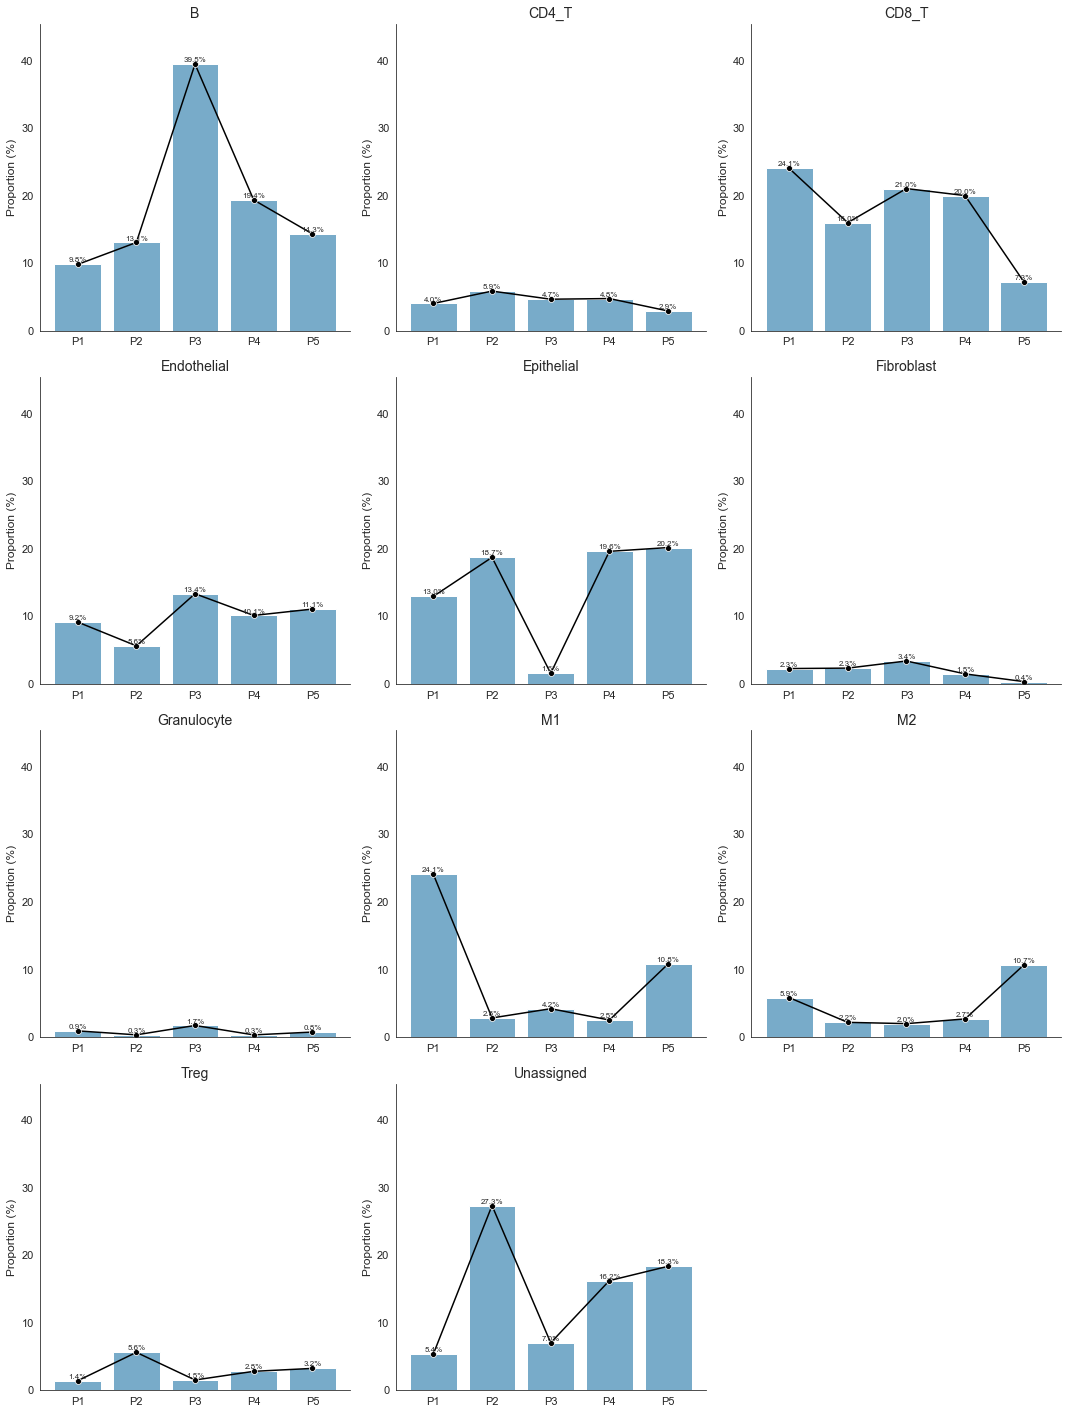

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# JCC风格全局设置
# =========================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9
})

sns.set_theme(style="white")

# =========================
# 1️⃣ 读取数据
# =========================
df = pd.read_csv(
    r"C:\Users\Li Chujia\Desktop\cell_annotationV2\annotated_cells_mixed.csv",
    encoding='gbk'
)

# =========================
# 2️⃣ 映射时期
# =========================
stage_map = {
    "T005": "P1",
    "T006": "P2",
    "T001": "P3",
    "T002": "P4",
    "T004": "P5"
}
df["Stage"] = df["标签"].map(stage_map)

# =========================
# 3️⃣ 过滤ROI（保持你的逻辑）
# =========================
mask = (df["标签"] != "T004") | (df["子标签"].isin(["ROI008", "ROI009", "ROI010"]))
df_filtered = df[mask].copy()

# =========================
# 4️⃣ 统计比例
# =========================
count_df = df_filtered.groupby(["Stage", "cell_type"]).size().reset_index(name="count")
total_per_stage = count_df.groupby("Stage")["count"].transform("sum")
count_df["percent"] = count_df["count"] / total_per_stage * 100

# =========================
# 5️⃣ 顺序控制（关键）
# =========================
stage_order = ["P1", "P2", "P3", "P4", "P5"]
count_df["Stage"] = pd.Categorical(count_df["Stage"], categories=stage_order, ordered=True)

# =========================
# 6️⃣ JCC风格颜色（与heatmap统一）
# =========================
bar_color = "#6baed6"  # 柔和蓝（与之前heatmap风格一致）

# =========================
# 7️⃣ 作图
# =========================
cell_types = count_df["cell_type"].unique()
num_types = len(cell_types)

fig, axes = plt.subplots(
    nrows=(num_types + 2)//3,
    ncols=3,
    figsize=(15, num_types * 1.8),
    facecolor="white"
)

axes = axes.flatten()

for i, cell in enumerate(cell_types):
    ax = axes[i]
    sub = count_df[count_df["cell_type"] == cell]

    # barplot（主视觉）
    sns.barplot(
        data=sub,
        x="Stage",
        y="percent",
        color=bar_color,
        ax=ax
    )

    # trend line（增强可读性）
    sns.lineplot(
        data=sub,
        x="Stage",
        y="percent",
        marker="o",
        color="black",
        ax=ax
    )

    # 数值标注
    for _, row in sub.iterrows():
        ax.text(
            row["Stage"],
            row["percent"] + 0.3,
            f"{row['percent']:.1f}%",
            ha="center",
            fontsize=8
        )

    # =========================
    # 标题（你可手动调大小的地方）
    # =========================
    ax.set_title(
        cell,
        fontsize=14,   # ← 这里可自由调整
        pad=6
    )

    ax.set_xlabel("")
    ax.set_ylabel("Proportion (%)")

    ax.set_ylim(0, count_df["percent"].max() * 1.15)

    # JCC风格：去边框
    # JCC风格坐标轴
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(True)
    ax.spines["bottom"].set_visible(True)

    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    ax.tick_params(axis='both', direction='out', length=3, width=0.8)

# 删除空子图
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# =========================
# 布局优化
# =========================
plt.tight_layout()

# =========================
# 输出
# =========================
plt.savefig(
    "Fig1d_stage_barplot.tiff",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    "Fig1d_stage_barplot.pdf",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

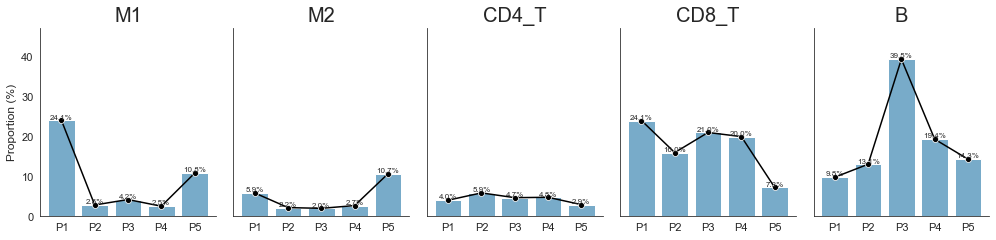

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# JCC风格
# =========================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10,
})

sns.set_theme(style="white")

# =========================
# 1️⃣ 读取数据
# =========================
df = pd.read_csv(
    r"C:\Users\Li Chujia\Desktop\cell_annotationV2\annotated_cells_mixed.csv",
    encoding='gbk'
)

# =========================
# 2️⃣ Stage映射
# =========================
stage_map = {
    "T005": "P1",
    "T006": "P2",
    "T001": "P3",
    "T002": "P4",
    "T004": "P5"
}
df["Stage"] = df["标签"].map(stage_map)

# =========================
# 3️⃣ ROI过滤
# =========================
mask = (df["标签"] != "T004") | (df["子标签"].isin(["ROI008", "ROI009", "ROI010"]))
df = df[mask].copy()

# =========================
# 4️⃣ 统计比例
# =========================
count_df = df.groupby(["Stage", "cell_type"]).size().reset_index(name="count")
total = count_df.groupby("Stage")["count"].transform("sum")
count_df["percent"] = count_df["count"] / total * 100

# Stage顺序
stage_order = ["P1", "P2", "P3", "P4", "P5"]
count_df["Stage"] = pd.Categorical(count_df["Stage"], categories=stage_order, ordered=True)

# =========================
# 5️⃣ 目标细胞顺序（你指定）
# =========================
target_cells = ["M1", "M2", "CD4_T", "CD8_T", "B"]

# 颜色
bar_color = "#6baed6"

# =========================
# 6️⃣ 画图（1×5）
# =========================
fig, axes = plt.subplots(
    nrows=1,
    ncols=5,
    figsize=(14, 3.5),
    sharey=True
)

for i, cell in enumerate(target_cells):
    ax = axes[i]
    sub = count_df[count_df["cell_type"] == cell]

    sns.barplot(
    data=sub,
    x="Stage",
    y="percent",
    color=bar_color,
    ax=ax,
    width=0.8
    )

    sns.lineplot(
        data=sub,
        x="Stage",
        y="percent",
        marker="o",
        color="black",
        ax=ax
    )

    # 数值标注
    for _, row in sub.iterrows():
        ax.text(
            row["Stage"],
            row["percent"] + 0.3,
            f"{row['percent']:.1f}%",
            ha="center",
            fontsize=8
        )

    # 标题
    ax.set_title(cell, fontsize=20)

    # 坐标轴
    ax.set_xlabel("")
    ax.set_ylabel("Proportion (%)" if i == 0 else "")

    # JCC风格边框
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    ax.tick_params(axis='both', direction='out', length=3, width=0.8)

    ax.set_ylim(0, count_df["percent"].max() * 1.2)

# =========================
# 布局
# =========================
plt.tight_layout()
plt.subplots_adjust(wspace=0.1)

# =========================
# 输出
# =========================
plt.savefig("Fig1d_5cell_1row.tiff", dpi=600, bbox_inches="tight")
plt.savefig("Fig1d_5cell_1row.pdf", bbox_inches="tight")

plt.show()